# Step 13 — Walk-forward robustness testing

We test six later periods sequentially. Training always uses only earlier dates and expands over time. Each fold removes the final five eligible training rows as a safety gap. Headline count is excluded following the ablation result.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "aapl_momentum_sentiment.csv"
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "walk_forward_results.csv"
data = pd.read_csv(DATA_PATH, parse_dates=["date"], index_col="date").sort_index()
data = data.loc[:"2024-11-22"].copy()

In [2]:
test_periods = [
    ("2023 Q3", "2023-07-01", "2023-09-30"),
    ("2023 Q4", "2023-10-01", "2023-12-31"),
    ("2024 Q1", "2024-01-01", "2024-03-31"),
    ("2024 Q2", "2024-04-01", "2024-06-30"),
    ("2024 Q3", "2024-07-01", "2024-09-30"),
    ("2024 Q4 through Nov 22", "2024-10-01", "2024-11-22"),
]
feature_sets = {
    "Momentum only": ["aapl_momentum_5d"],
    "Tone only": ["average_sentiment_5d"],
    "Momentum + tone": ["aapl_momentum_5d", "average_sentiment_5d"],
}

## Evaluate every period

For each fold, the majority class and all model parameters are learned again from that fold's training data.

In [3]:
rows = []
coefficient_rows = []
for period_name, start, end in test_periods:
    test = data.loc[start:end].copy()
    earlier = data.loc[data.index < test.index.min()].copy()
    train = earlier.iloc[:-5].copy()
    y_train = train["outperformed"].astype(int)
    y_test = test["outperformed"].astype(int)

    majority_class = int(y_train.mode().iloc[0])
    majority_prediction = pd.Series(majority_class, index=test.index)
    rows.append({
        "Period": period_name,
        "Model": "Majority baseline",
        "Training rows": len(train),
        "Test rows": len(test),
        "Accuracy": accuracy_score(y_test, majority_prediction),
        "ROC AUC": 0.5,
    })

    for model_name, features in feature_sets.items():
        model = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))
        model.fit(train[features], y_train)
        prediction = model.predict(test[features])
        probability = model.predict_proba(test[features])[:, 1]
        rows.append({
            "Period": period_name,
            "Model": model_name,
            "Training rows": len(train),
            "Test rows": len(test),
            "Accuracy": accuracy_score(y_test, prediction),
            "ROC AUC": roc_auc_score(y_test, probability),
        })
        for feature, coefficient in zip(
            features, model.named_steps["logisticregression"].coef_[0]
        ):
            coefficient_rows.append({
                "Period": period_name,
                "Model": model_name,
                "Feature": feature,
                "Coefficient": coefficient,
            })

results = pd.DataFrame(rows)
coefficients = pd.DataFrame(coefficient_rows)
results.to_csv(OUTPUT_PATH, index=False)
results.pivot(index="Period", columns="Model", values="Accuracy").round(3)

Model,Majority baseline,Momentum + tone,Momentum only,Tone only
Period,,,,
2023 Q3,0.524,0.524,0.524,0.524
2023 Q4,0.429,0.444,0.365,0.429
2024 Q1,0.230,0.262,0.279,0.230
2024 Q2,0.698,0.603,0.619,0.556
2024 Q3,0.422,0.438,0.406,0.516
2024 Q4 through Nov 22,0.564,0.513,0.513,0.487


## Summarize consistency

The weighted averages account for unequal period lengths. A model win means its accuracy exceeded the majority baseline in that period.

In [4]:
baseline_by_period = (
    results.loc[results["Model"].eq("Majority baseline"), ["Period", "Accuracy"]]
    .set_index("Period")["Accuracy"]
)
summary_rows = []
for model_name, group in results.groupby("Model"):
    weighted_accuracy = (group["Accuracy"] * group["Test rows"]).sum() / group["Test rows"].sum()
    weighted_auc = (group["ROC AUC"] * group["Test rows"]).sum() / group["Test rows"].sum()
    wins = sum(
        row["Accuracy"] > baseline_by_period.loc[row["Period"]]
        for _, row in group.iterrows()
    ) if model_name != "Majority baseline" else pd.NA
    summary_rows.append({
        "Model": model_name,
        "Weighted accuracy": weighted_accuracy,
        "Weighted ROC AUC": weighted_auc,
        "Periods beating baseline": wins,
    })
summary = pd.DataFrame(summary_rows).set_index("Model")
summary.round(3)

,Weighted accuracy,Weighted ROC AUC,Periods beating baseline
Model,,,
Majority baseline,0.473,0.500,<NA>
Momentum + tone,0.462,0.597,3
Momentum only,0.448,0.555,1
Tone only,0.456,0.638,1


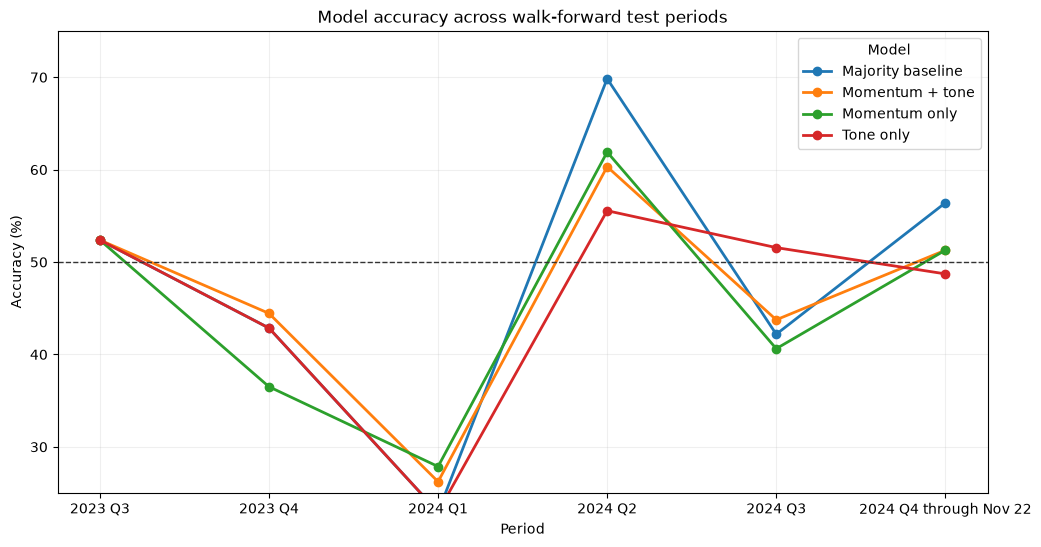

In [5]:
accuracy_table = results.pivot(index="Period", columns="Model", values="Accuracy") * 100
ax = accuracy_table.plot(figsize=(12, 6), marker="o", linewidth=2)
ax.axhline(50, color="#333333", linestyle="--", linewidth=1)
ax.set_ylim(25, 75)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model accuracy across walk-forward test periods")
ax.grid(alpha=0.2)
plt.show()

## Check whether the learned relationship changes

A stable tone signal should generally retain the same coefficient direction as training expands.

In [6]:
coefficients.loc[coefficients["Feature"].eq("average_sentiment_5d")].pivot(
    index="Period", columns="Model", values="Coefficient"
).round(3)

Model,Momentum + tone,Tone only
Period,,
2023 Q3,-0.080,-0.074
2023 Q4,-0.187,-0.249
2024 Q1,-0.198,-0.232
2024 Q2,-0.054,-0.084
2024 Q3,-0.033,-0.071
2024 Q4 through Nov 22,-0.182,-0.200


## Limitations

The same observations can appear in several expanding training sets, and neighboring five-day targets overlap. These period results diagnose stability but are not six independent experiments.